# Risk Prediction using Machine Learning
The objective of this notebook is to build machine learning models capable of predicting borrower credit risk. Multiple classification algorithms are trained and evaluated to identify the most effective model for distinguishing between good and bad borrowers.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv("german_credit_data.csv")

df.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [3]:
categorical_columns = df.select_dtypes( include="object" ).columns 
for col in categorical_columns: 
    df[col] = df[col].fillna( df[col].mode()[0] )

# Encode Categorical Variables

Machine learning models require numerical inputs. Label Encoding is applied to convert categorical variables into numeric form.

In [4]:
encoder = LabelEncoder() 
for col in df.select_dtypes( 
    include="object" ).columns: 
    df[col] = encoder.fit_transform( df[col] )

In [ ]:
# Feature Selection
X = df.drop(
    "target",
    axis=1
)

y = df["target"]

In [7]:
# Feature Selection
X = df.drop(
    "target",
    axis=1
)

y = df["target"]

# Train-Test Split

80% of the data is used for training and 20% for testing.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(800, 20)
(200, 20)


# Model 1: Logistic Regression

Logistic Regression serves as a baseline classification model.

In [10]:
lr_model = LogisticRegression(
    max_iter=10000
)

lr_model.fit(
    X_train,
    y_train
)
# Predictions
lr_pred = lr_model.predict(X_test)

# Evaluation
print(classification_report(y_test,lr_pred))
print("Accuracy:",accuracy_score(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.55      0.40      0.46        60
           1       0.77      0.86      0.81       140

    accuracy                           0.72       200
   macro avg       0.66      0.63      0.64       200
weighted avg       0.70      0.72      0.71       200

Accuracy: 0.72


# Model 2: Random Forest

Random Forest combines multiple decision trees to improve predictive performance.

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)
# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
print(classification_report(y_test,rf_pred))
print("Accuracy:",accuracy_score(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.66      0.42      0.51        60
           1       0.78      0.91      0.84       140

    accuracy                           0.76       200
   macro avg       0.72      0.66      0.68       200
weighted avg       0.75      0.76      0.74       200

Accuracy: 0.76


# Model 3: Gradient Boosting

Gradient Boosting improves performance by sequentially correcting previous errors.

In [12]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train,y_train)

# Predictions
gb_pred = gb_model.predict(X_test)

# Evaluation
print(classification_report(y_test,gb_pred))

print("Accuracy:",accuracy_score(y_test,gb_pred))

              precision    recall  f1-score   support

           0       0.67      0.50      0.57        60
           1       0.81      0.89      0.85       140

    accuracy                           0.78       200
   macro avg       0.74      0.70      0.71       200
weighted avg       0.76      0.78      0.76       200

Accuracy: 0.775


## Model Comparison

In [13]:
results = pd.DataFrame({ 
    "Model":[ "Logistic Regression", "Random Forest", "Gradient Boosting" ], 
    "Accuracy":[ accuracy_score( y_test, lr_pred ), 
                accuracy_score( y_test, rf_pred ), 
                accuracy_score( y_test, gb_pred ) ] 
}) 
results.sort_values( by="Accuracy", ascending= False )

,Model,Accuracy
2,Gradient Boosting,0.775
1,Random Forest,0.760
0,Logistic Regression,0.720


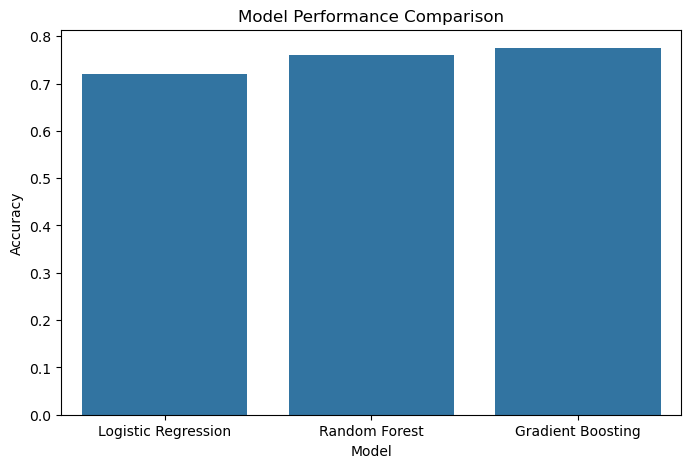

In [14]:
# Visual Comparison
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Performance Comparison")

plt.show()

# Confusion Matrix for Best Model

Replace rf_pred with the best-performing model if necessary.

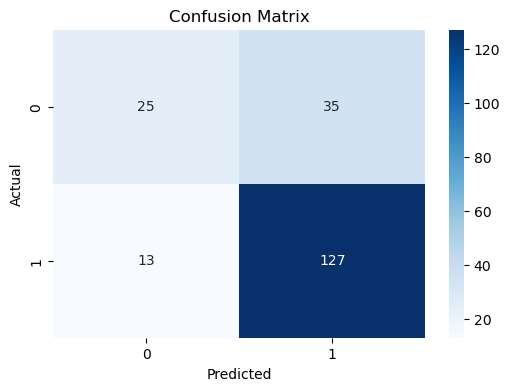

In [16]:
cm = confusion_matrix( y_test, rf_pred ) 
plt.figure(figsize=(6,4)) 
sns.heatmap( cm, annot=True, fmt="d", cmap="Blues" ) 
plt.title( "Confusion Matrix" ) 
plt.xlabel( "Predicted" ) 
plt.ylabel( "Actual" ) 
plt.show()

# ROC-AUC measures the model's ability to distinguish between good and bad borrowers across different classification thresholds.

# A score closer to 1 indicates stronger discrimination capability.

In [19]:
# Add Predicted Probabilities
# Logistic Regression

lr_prob = lr_model.predict_proba(
    X_test
)[:,1]

# Random Forest

rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

# Gradient Boosting

gb_prob = gb_model.predict_proba(
    X_test
)[:,1]

In [20]:
# ROC-AUC Scores
from sklearn.metrics import roc_auc_score

print(
    "Logistic Regression ROC-AUC:",
    roc_auc_score(y_test, lr_prob)
)

print(
    "Random Forest ROC-AUC:",
    roc_auc_score(y_test, rf_prob)
)

print(
    "Gradient Boosting ROC-AUC:",
    roc_auc_score(y_test, gb_prob)
)

Logistic Regression ROC-AUC: 0.7382142857142858
Random Forest ROC-AUC: 0.799047619047619
Gradient Boosting ROC-AUC: 0.7848809523809523


In [22]:
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

gb_fpr, gb_tpr, _ = roc_curve(
    y_test,
    gb_prob
)

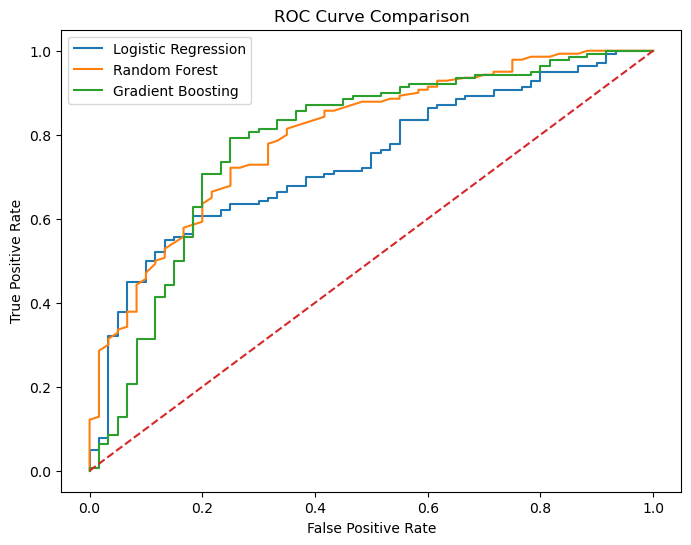

In [23]:
plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label="Gradient Boosting"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.show()

# Feature Importance

Understanding which variables influence credit risk is important for explainability.

             Feature  Importance
4      credit_amount    0.140027
0     status_account    0.109340
12               age    0.104766
1     month_duration    0.102926
3            purpose    0.066063
11        collateral    0.050737
2     credit_history    0.048485
6   years_employment    0.047542
5     status_savings    0.044622
10   residence_since    0.043421


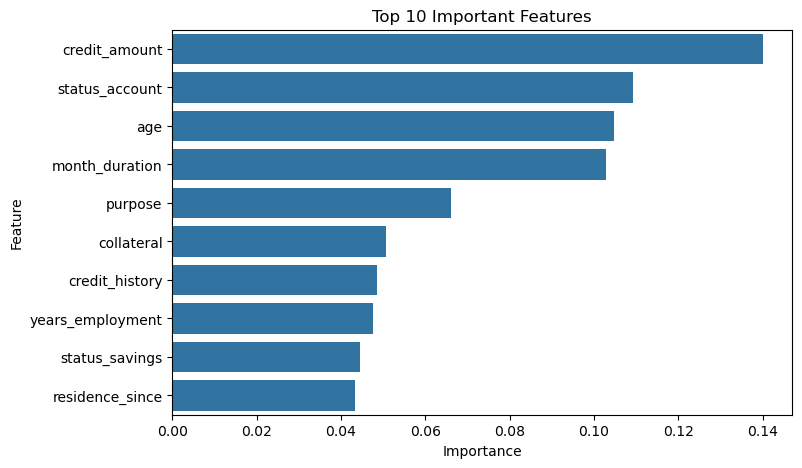

In [18]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

# Key Findings
--Three machine learning models were evaluated.
--Random Forest and Gradient Boosting captured complex borrower behavior more   effectively than Logistic Regression.
--Feature importance analysis identified the most influential variables affecting credit risk.
--Machine learning models demonstrated strong potential for supporting lending decisions and risk management.

# Conclusion

This notebook developed and evaluated multiple machine learning models for credit risk prediction.

The best-performing model will be used as the foundation for the financial stability and stress testing analysis presented in the next notebook.